# Notebook 2 — 10X-cell ground truth → gene cell-type probabilities

Produces a **per-gene cell-type probability table** that notebook 01 uses to
estimate boundary likelihood from mRNA gradients.

**Pipeline:**
0. Setup
1. Read 10X-segmented cells (cell × gene matrix + metadata)
2. QC cells
3. PCA → Harmony → UMAP → clustering
4. Markers (`presto::wilcoxauc`)
5. Cluster annotation, two-level mapping, gene × cell-type count matrix, gene specificity, **per-gene lineage labels**
6. Export to parquet for notebook 01

**Handoff to notebook 01:**
- `<DATA_ROOT>/gene_celltype_counts_{fine,lineage}.parquet` — raw count matrices.
- `<DATA_ROOT>/gene_labels_lineage.parquet` — one row per gene with `label ∈ {7 lineage names, "ambiguous"}`. Notebook 01 consumes this directly; no filter logic there.

## 0. Setup

Determinism note: PCA (via irlba), UMAP, and graph clustering all have stochastic components. We pin three things to make re-runs bit-identical:
1. `set.seed(SEED)` at the top of the R session.
2. Explicit `seed.use = SEED` and `random.seed = SEED` on every Seurat call below.
3. BLAS/OMP single-thread — multi-thread BLAS schedules vary run-to-run and is the dominant cause of "I clustered the same data twice and got different cluster IDs."


In [91]:
SEED <- 42L

# Lock down BLAS / OMP thread count so PCA is reproducible across re-runs.
# Must happen BEFORE any heavy linear algebra; setting in the same process
# works for OpenBLAS / Accelerate / MKL on macOS.
Sys.setenv(OMP_NUM_THREADS = "1", OPENBLAS_NUM_THREADS = "1",
           MKL_NUM_THREADS = "1", VECLIB_MAXIMUM_THREADS = "1",
           NUMEXPR_NUM_THREADS = "1")
if ("RhpcBLASctl" %in% rownames(installed.packages())) {
  RhpcBLASctl::blas_set_num_threads(1)
  RhpcBLASctl::omp_set_num_threads(1)
}

suppressPackageStartupMessages({
  library(arrow); library(dplyr); library(ggplot2); library(Matrix)
  # Add the rest of your usual stack as needed:
  # library(Seurat); library(harmony); library(uwot); library(patchwork)
})
if (requireNamespace("data.table", quietly = TRUE)) data.table::setDTthreads(1)
set.seed(SEED)

DATA_ROOT <- "/Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs"
CELLS_DIR <- file.path(DATA_ROOT, "cells_extracted")
cat("data root:", DATA_ROOT, "\n")
cat("cells extracted dir:", CELLS_DIR, "\n")

data root: /Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs 
cells extracted dir: /Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs/cells_extracted 


## 1. Read 10X-segmented cells

Xenium stores cells in zarr (`cells.zarr.zip` + `cell_feature_matrix.zarr.zip`), which is awkward in R. A one-time Python conversion writes a standard 10X-format directory (`barcodes.tsv.gz`, `features.tsv.gz`, `matrix.mtx.gz`) plus a `cells_meta.parquet` with centroids/areas.

The cell below runs the conversion if `cells_extracted/` doesn't exist; otherwise it skips. Re-run manually only if you re-download data.

**Output dir layout** (after extraction):
- `matrix.mtx.gz` — features × cells, gzipped MatrixMarket  *(10X convention)*
- `features.tsv.gz` — `(gene_id, gene_symbol, feature_type)`
- `barcodes.tsv.gz` — cell barcodes (`cell_<id>_<seg>`)
- `cells_meta.parquet` — `(barcode, x_um, y_um, area_um2, nucleus_x_um, nucleus_y_um, nucleus_area_um2, z_level, nucleus_count, n_counts, n_features)`

In [92]:
if (!file.exists(file.path(CELLS_DIR, "matrix.mtx.gz"))) {
  PY     <- "/Users/ik936/miniconda3/envs/omnipose/bin/python"
  SCRIPT <- "/Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/scripts/extract_xenium_cells_to_10x.py"
  cat("extracting (one-time, takes ~1 min)…\n")
  out <- system2(PY, args = c(shQuote(SCRIPT), shQuote(DATA_ROOT)),
                 stdout = TRUE, stderr = TRUE)
  cat(out, sep = "\n")
} else {
  cat("cells_extracted/ already present — skipping conversion\n")
}

cells_extracted/ already present — skipping conversion


In [93]:
# ─── Load: count matrix (features × cells), feature table, cell metadata ──
mat      <- readMM(file.path(CELLS_DIR, "matrix.mtx.gz"))
features <- read.table(gzfile(file.path(CELLS_DIR, "features.tsv.gz")),
                       sep = "\t", stringsAsFactors = FALSE,
                       col.names = c("gene_id", "gene_symbol", "feature_type"))
barcodes <- readLines(gzfile(file.path(CELLS_DIR, "barcodes.tsv.gz")))
cells_meta <- read_parquet(file.path(CELLS_DIR, "cells_meta.parquet"))

# Name rows/cols so downstream code can be by-name
rownames(mat) <- make.unique(features$gene_symbol)
colnames(mat) <- barcodes

cat(sprintf("matrix: %d features × %d cells   nnz: %s\n",
            nrow(mat), ncol(mat), format(length(mat@x), big.mark = ",")))
cat("feature_types:\n")
print(table(features$feature_type))
cat("\ncells_meta:\n")
glimpse(cells_meta)

matrix: 10018 features × 112551 cells   nnz: 33,431,898
feature_types:

           aggregate_gene       deprecated_codeword                      gene 
                        1                       310                      5006 
          genomic_control negative_control_codeword    negative_control_probe 
                       21                       609                        40 
      unassigned_codeword 
                     4031 

cells_meta:
Rows: 112,551
Columns: 11
$ barcode          <chr> "cell_47497_1", "cell_91435_1", "cell_157601_1", "cel…
$ x_um             <dbl> 174.19957, 183.11928, 186.32860, 169.92171, 161.51326…
$ y_um             <dbl> 2299.126, 2270.192, 2258.269, 2272.070, 2279.989, 230…
$ area_um2         <dbl> 489.71955, 333.16282, 254.27485, 332.66611, 79.97172,…
$ nucleus_x_um     <dbl> 173.5447, 184.2719, 183.7676, 165.3257, NA, NA, NA, N…
$ nucleus_y_um     <dbl> 2297.909, 2271.489, 2256.217, 2272.162, NA, NA, NA, N…
$ nucleus_area_um2 <dbl> 70.08250, 58.5

### Sanity-check viz — cell centroids colored by log10(n_counts)

A quick eyeball: are the cells spatially distributed as expected, do count-rich regions correspond to dense tissue, are there obvious artifacts?

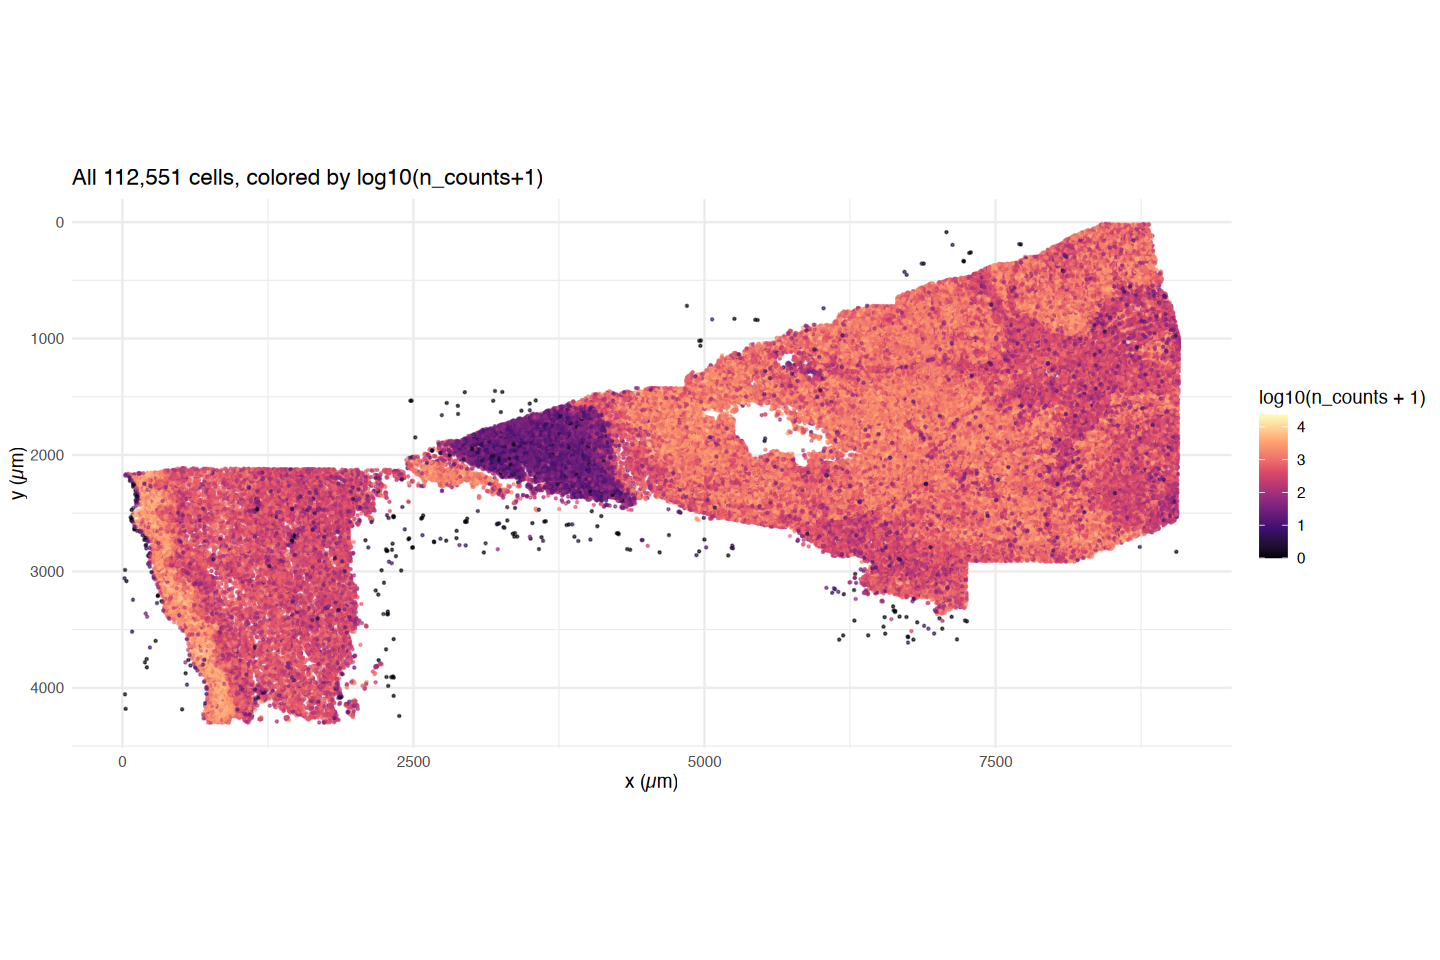

In [94]:
options(repr.plot.width = 12, repr.plot.height = 8)
ggplot(cells_meta, aes(x = x_um, y = y_um, color = log10(n_counts + 1))) +
  geom_point(size = 0.2, alpha = 0.6) +
  scale_color_viridis_c(option = "magma") +
  coord_fixed() +
  scale_y_reverse() +   # image coordinates
  theme_minimal() +
  labs(title = sprintf("All %s cells, colored by log10(n_counts+1)",
                       format(nrow(cells_meta), big.mark = ",")),
       x = "x (µm)", y = "y (µm)")

## 2. QC cells

Drop non-gene feature rows (negative controls, codewords) and filter cells by per-cell metrics. Thresholds below are reasonable starting points — tune empirically by looking at the histograms.

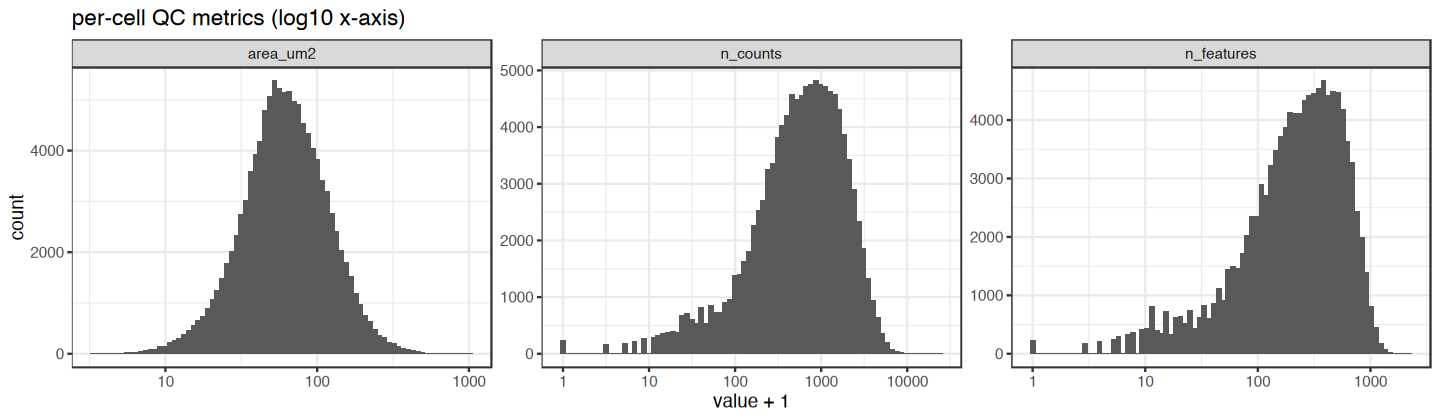

In [95]:
# ─── Distribution plots so you can pick thresholds ────────────────────
options(repr.plot.width = 12, repr.plot.height = 3.5)
qc_df <- cells_meta |>
  select(n_counts, n_features, area_um2) |>
  tidyr::pivot_longer(everything(), names_to = "metric", values_to = "value")

ggplot(qc_df, aes(x = value + 1)) +
  geom_histogram(bins = 80) +
  scale_x_log10() +
  facet_wrap(~ metric, scales = "free") +
  theme_bw() +
  labs(title = "per-cell QC metrics (log10 x-axis)")

In [96]:
# ─── Filters: tune these by looking at the histograms above ──────────
MIN_COUNTS    <- 300
MIN_FEATURES  <- 100
MIN_AREA_UM2  <- 10
MAX_AREA_UM2  <- 2000

# Drop non-gene rows from the matrix
gene_rows   <- which(features$feature_type == "gene")
features_qc <- features[gene_rows, ]

# Cell mask
keep_cells <- with(cells_meta,
                   n_counts   >= MIN_COUNTS    &
                   n_features >= MIN_FEATURES  &
                   area_um2   >= MIN_AREA_UM2  &
                   area_um2   <= MAX_AREA_UM2)

mat_qc        <- mat[gene_rows, keep_cells]
cells_meta_qc <- cells_meta[keep_cells, ]
rownames(cells_meta_qc) <- NULL

cat(sprintf("after QC: %d cells (kept %.1f%%), %d genes\n",
            sum(keep_cells), 100 * mean(keep_cells), length(gene_rows)))

after QC: 80121 cells (kept 71.2%), 5006 genes


## 3. PCA → Harmony → UMAP → clustering

Default flow: Seurat normalize → variable features → scale → PCA → optional Harmony → UMAP → graph clustering. Slow on 100k+ cells (5–10 min); subset `mat_qc[, sample(ncol(mat_qc), 10000)]` for prototyping if needed.

In [97]:
suppressPackageStartupMessages({
  library(Seurat); library(harmony)
})

# ─── tunables ─────────────────────────────────────────────────────────
N_VAR_FEATURES <- 3000
N_PCS          <- 10
RES            <- 0.5            # Leiden/Louvain resolution
NORM_SCALE     <- 1000           # NormalizeData scale.factor (10X default is 1e4)
BATCH_VAR      <- NULL           # e.g. "z_level" if you want Harmony; NULL = skip
# ──────────────────────────────────────────────────────────────────────

set.seed(SEED)
so <- CreateSeuratObject(counts = mat_qc, meta.data = cells_meta_qc) |>
  NormalizeData(scale.factor = NORM_SCALE, verbose = FALSE) |>
  FindVariableFeatures(nfeatures = N_VAR_FEATURES, verbose = FALSE) |>
  ScaleData(verbose = FALSE) |>
  RunPCA(npcs = N_PCS, seed.use = SEED, verbose = FALSE)

if (!is.null(BATCH_VAR)) {
  so <- RunHarmony(so, BATCH_VAR, verbose = FALSE)
  REDUC <- "harmony"
} else {
  REDUC <- "pca"
}

set.seed(SEED)
so <- so |>
  RunUMAP(reduction = REDUC, dims = 1:N_PCS, seed.use = SEED, verbose = FALSE) |>
  FindNeighbors(reduction = REDUC, dims = 1:N_PCS, verbose = FALSE) |>
  FindClusters(resolution = RES, random.seed = SEED, verbose = FALSE)

# Pull cluster + UMAP back into cells_meta_qc
cells_meta_qc$cluster <- as.character(Idents(so))
umap_emb <- Embeddings(so, "umap")
cells_meta_qc$UMAP_1 <- umap_emb[, 1]
cells_meta_qc$UMAP_2 <- umap_emb[, 2]

cat(sprintf("clustered into %d clusters\n", length(unique(cells_meta_qc$cluster))))
print(table(cells_meta_qc$cluster))

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”
Warning message:
“Setting row names on a tibble is deprecated.”


clustered into 15 clusters

    0     1    10    11    12    13    14     2     3     4     5     6     7 
12428 11845  3081  2981  1918  1797   857  7778  7505  7057  6438  5937  4165 
    8     9 
 3192  3142 


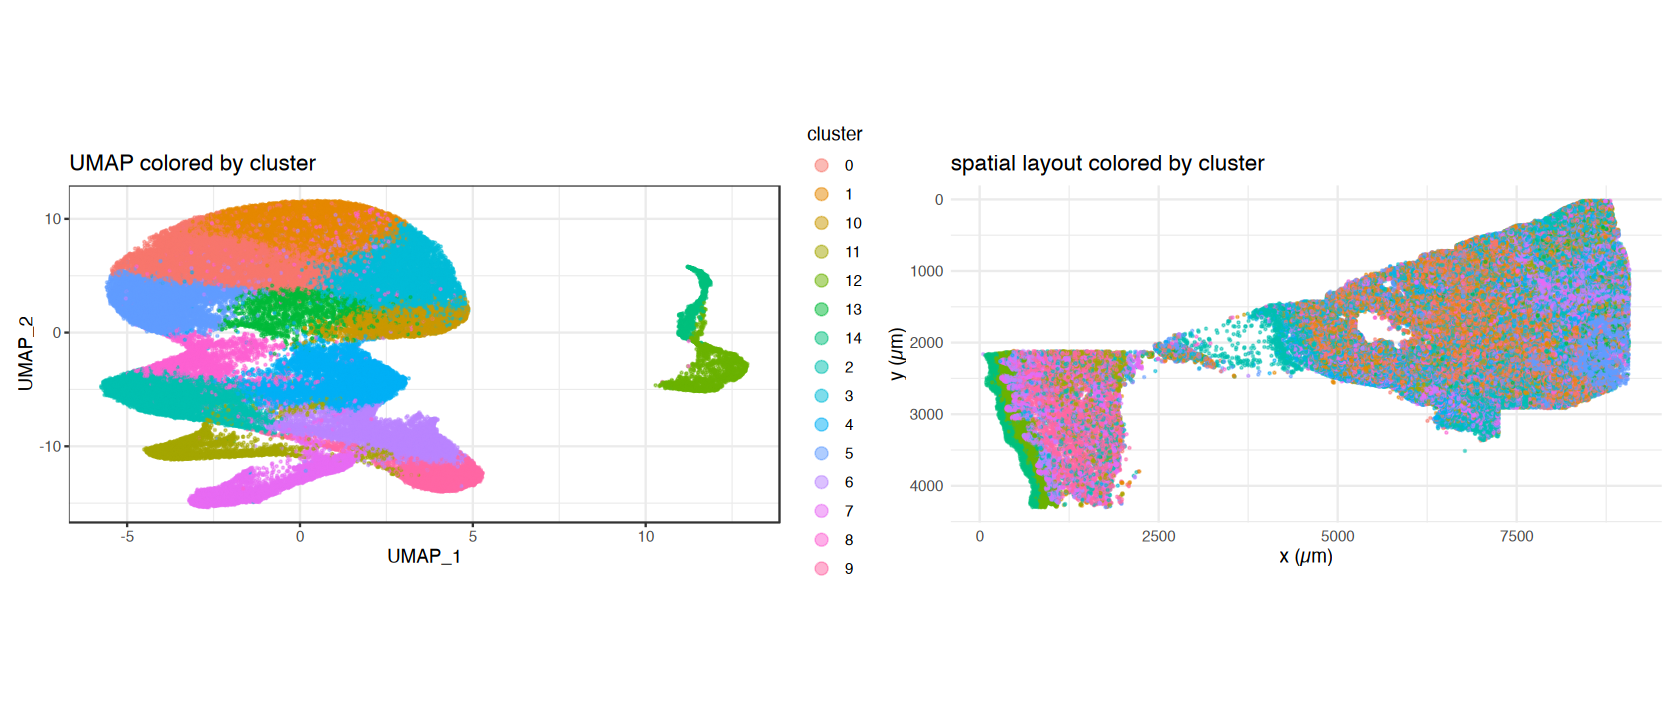

In [98]:
# UMAP + spatial colored by cluster
options(repr.plot.width = 14, repr.plot.height = 6)
p_umap <- ggplot(cells_meta_qc, aes(UMAP_1, UMAP_2, color = cluster)) +
  geom_point(size = 0.2, alpha = 0.5) +
  guides(color = guide_legend(override.aes = list(size = 3))) +
  theme_bw() + labs(title = "UMAP colored by cluster")

p_spatial <- ggplot(cells_meta_qc, aes(x_um, y_um, color = cluster)) +
  geom_point(size = 0.2, alpha = 0.5) +
  coord_fixed() + scale_y_reverse() +
  guides(color = "none") +
  theme_minimal() + labs(title = "spatial layout colored by cluster",
                          x = "x (µm)", y = "y (µm)")

(p_umap | p_spatial)

## 4. Markers — `presto::wilcoxauc`

Per-cluster differential expression via `presto::wilcoxauc` — Korsunsky-lab's vectorized C++ implementation. Returns a tidy data frame with `feature, group, avgExpr, logFC, statistic, auc, pval, padj, pct_in, pct_out` — directly usable for ranking and filtering.

Not using `Seurat::FindAllMarkers(test.use = "wilcox")` here: it loops in R, runs minutes-to-hours on this scale; presto runs in seconds.

In [99]:
suppressPackageStartupMessages(library(presto))

# presto's `wilcoxauc(<Seurat>, ...)` method hits a deprecated GetAssayData(slot=)
# call on Seurat 5.0+. Bypass by extracting the matrix + group vector ourselves
# and calling the matrix method directly.
X <- Seurat::GetAssayData(so, layer = "data")        # log-normalized values
y <- as.character(Idents(so))                         # cluster labels

t0 <- Sys.time()
markers <- wilcoxauc(X, y)
cat(sprintf("wilcoxauc: %d tests in %.1f s\n",
            nrow(markers), as.numeric(difftime(Sys.time(), t0, units = "secs"))))
head(markers, 5)

wilcoxauc: 75090 tests in 2.2 s


,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A2ML1,0,0.0002586319,-0.031461832,411448816,0.4890698,2.188079e-61,1.454651e-60,0.02413904,2.2099774
2,AAMP,0,0.2320362156,0.062697790,442121959,0.5255295,6.814063e-40,3.150150e-39,22.51367879,18.4391296
3,AAR2,0,0.0618815291,0.008455105,423205704,0.5030446,8.724078e-03,1.290565e-02,6.46926295,5.9311893
4,AARSD1,0,0.0785279068,0.015376287,423395566,0.5032703,1.036579e-02,1.521734e-02,7.76472481,7.2917436
5,ABAT,0,0.0051281411,-0.004125037,419448146,0.4985782,8.095778e-04,1.307338e-03,0.52301255,0.8065827


In [100]:
# Top markers per cluster
TOP_N_PER_CLUSTER <- 5

top_markers <- markers |>
  filter(padj < 0.05, logFC > 0) |>
  group_by(group) |>
  slice_max(auc, n = TOP_N_PER_CLUSTER) |>
  ungroup() |>
  arrange(group, desc(auc))

cat(sprintf("top %d markers per cluster (%d total):\n",
            TOP_N_PER_CLUSTER, nrow(top_markers)))
print(top_markers |> select(group, feature, auc, logFC, pct_in, pct_out), n = 50)

top 5 markers per cluster (75 total):
# A tibble: 75 × 6
   group feature   auc logFC pct_in pct_out
   <chr> <chr>   <dbl> <dbl>  <dbl>   <dbl>
 1 0     S100A1  0.775 1.44    99.6  58.9  
 2 0     ADGRG1  0.762 1.01    94.2  51.9  
 3 0     FBL     0.761 0.972   97.6  64.9  
 4 0     ATP1A1  0.751 0.922   96.5  61.3  
 5 0     MLANA   0.741 0.855   89.7  46.3  
 6 1     ADGRG1  0.786 1.09    98.3  51.6  
 7 1     MLANA   0.782 0.987   96.8  45.5  
 8 1     AKT2    0.774 0.889   98.2  53.5  
 9 1     ERBB3   0.772 0.760   90.7  38.0  
10 1     EDNRB   0.763 0.666   85.8  32.4  
11 10    BIRC5   0.923 1.23    92.4  13.2  
12 10    KPNA2   0.828 0.829   81.3  20.1  
13 10    TYMS    0.828 0.811   80.8  18.8  
14 10    TUBB    0.823 0.941   98.8  72.8  
15 10    PRR11   0.815 0.671   69.8   7.54 
16 11    XBP1    0.964 2.83    95.0  24.7  
17 11    MZB1    0.869 1.57    74.2   0.637
18 11    PIM2    0.864 1.72    75.0   5.33 
19 11    TENT5C  0.861 1.50    73.0   1.97 
20 11    POU2AF1 0.

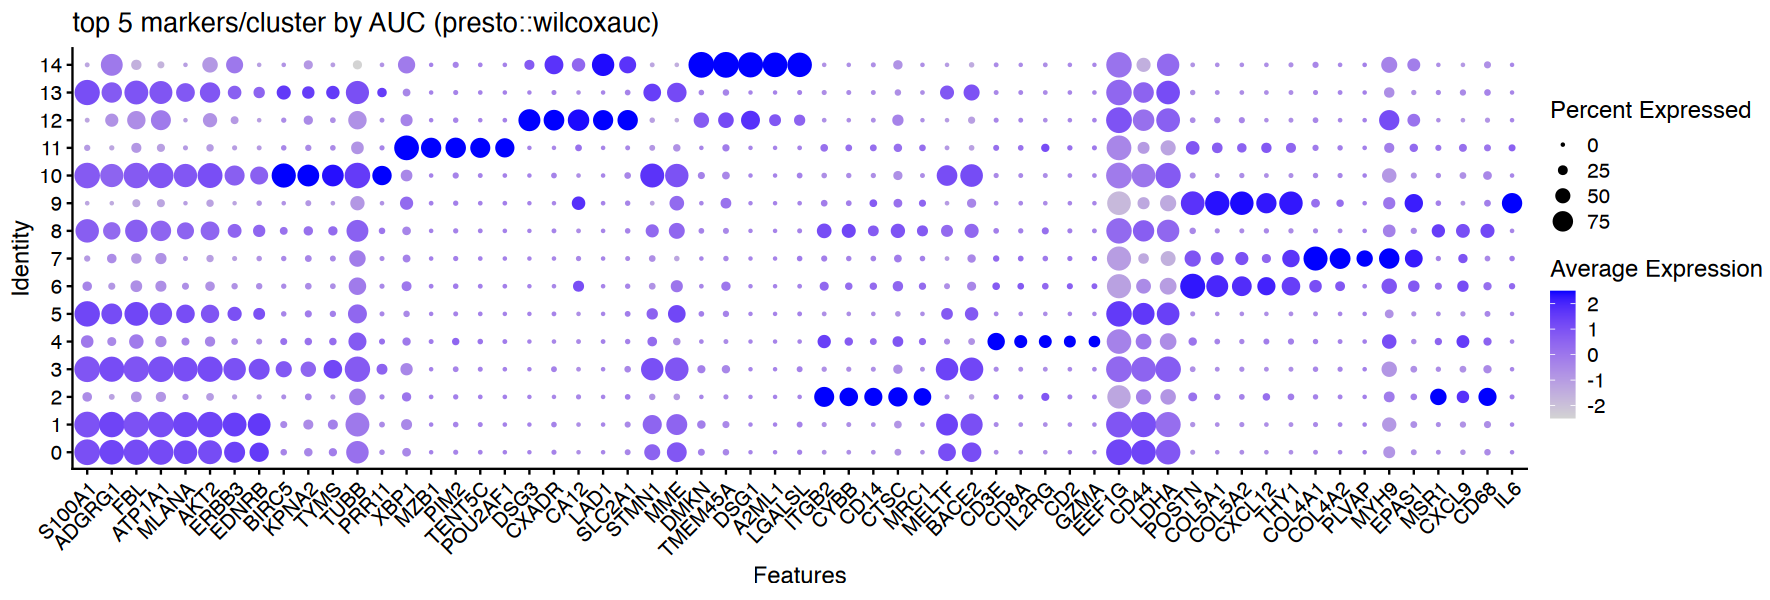

In [101]:
# DotPlot of the top-N markers across clusters — quick eyeball for cluster identity
top_gene_set <- unique(top_markers$feature)
options(repr.plot.width = max(8, 0.25 * length(top_gene_set)),
        repr.plot.height = max(5, 0.3 * length(unique(cells_meta_qc$cluster))))
Seurat::DotPlot(so, features = top_gene_set) +
  Seurat::RotatedAxis() +
  ggtitle(sprintf("top %d markers/cluster by AUC (presto::wilcoxauc)",
                  TOP_N_PER_CLUSTER))

## 5. Cluster annotation — two levels (fine + lineage)

Two-level annotation, hard-coded from the marker analysis on this dataset (clusters 0–14 from the seeded run):

- **fine** (15 labels) — separates melanoma differentiation states (main / MITF-high / S-phase / G2/M / non-distinctive / low-def) and macrophage activation states (TAM vs M1-like).
- **lineage** (7 labels) — collapses melanoma subtypes, fuses macrophage subtypes, fuses fibroblast + myCAF, fuses keratinocyte basal + suprabasal.

**Note:** these mappings are valid only for the seeded run of this notebook with the current parameters (N_VAR_FEATURES=3000, N_PCS=10, RES=0.5, SEED=42, single-thread BLAS). Re-running with different params can shuffle cluster IDs and invalidate the mapping — re-annotate before trusting downstream output.

In [102]:
# ─── Fine-level mapping: cluster ID → 15 cell-type labels ─────────────
cluster_to_fine <- c(
  "0"  = "Melanoma_main",
  "1"  = "Melanoma_MITFhigh",
  "2"  = "Macrophage_TAM",
  "3"  = "Melanoma_Sphase",
  "4"  = "Tcell",
  "5"  = "Melanoma_other",          # dedifferentiated / non-distinctive
  "6"  = "Fibroblast",
  "7"  = "Endothelial",
  "8"  = "Myeloid_inflammatory",
  "9"  = "myCAF",
  "10" = "Melanoma_G2M",
  "11" = "Plasma",
  "12" = "Keratinocyte_basal",
  "13" = "Melanoma_lowdef",         # low-confidence; consider merging with 5 or 0
  "14" = "Keratinocyte_suprabasal"
)

# ─── Lineage-level mapping: fine → 7 lineage labels ───────────────────
fine_to_lineage <- c(
  "Melanoma_main"           = "Melanoma",
  "Melanoma_MITFhigh"       = "Melanoma",
  "Melanoma_Sphase"         = "Melanoma",
  "Melanoma_G2M"            = "Melanoma",
  "Melanoma_other"          = "Melanoma",
  "Melanoma_lowdef"         = "Melanoma",
  "Macrophage_TAM"          = "Myeloid",
  "Myeloid_inflammatory"    = "Myeloid",
  "Tcell"                   = "Tcell",
  "Plasma"                  = "Plasma",
  "Fibroblast"              = "Fibroblast",
  "myCAF"                   = "Fibroblast",
  "Endothelial"             = "Endothelial",
  "Keratinocyte_basal"      = "Keratinocyte",
  "Keratinocyte_suprabasal" = "Keratinocyte"
)

cells_meta_qc$cell_type_fine    <- cluster_to_fine[as.character(cells_meta_qc$cluster)]
cells_meta_qc$cell_type_lineage <- fine_to_lineage[cells_meta_qc$cell_type_fine]

stopifnot(!anyNA(cells_meta_qc$cell_type_fine),
          !anyNA(cells_meta_qc$cell_type_lineage))

cat("fine-level counts:\n")
print(sort(table(cells_meta_qc$cell_type_fine),    decreasing = TRUE))
cat("\nlineage-level counts:\n")
print(sort(table(cells_meta_qc$cell_type_lineage), decreasing = TRUE))

fine-level counts:

          Melanoma_main       Melanoma_MITFhigh          Macrophage_TAM 
                  12428                   11845                    7778 
        Melanoma_Sphase                   Tcell          Melanoma_other 
                   7505                    7057                    6438 
             Fibroblast             Endothelial    Myeloid_inflammatory 
                   5937                    4165                    3192 
                  myCAF            Melanoma_G2M                  Plasma 
                   3142                    3081                    2981 
     Keratinocyte_basal         Melanoma_lowdef Keratinocyte_suprabasal 
                   1918                    1797                     857 

lineage-level counts:

    Melanoma      Myeloid   Fibroblast        Tcell  Endothelial       Plasma 
       43094        10970         9079         7057         4165         2981 
Keratinocyte 
        2775 


### 5b. Gene × cell-type **count** matrices (one per level)

Sum of counts per (gene, cell_type). **No normalization happens here** — that's the consumer's responsibility. Notebook 02 stays at the level of a cheap DGE matrix; notebook 01 (gradients) does column-normalize + per-gene z-score on-the-fly, the specificity analysis in §5d does column-normalize + row-renormalize. Different downstream uses want different normalizations, so we don't commit to one here.

In [103]:
compute_gene_celltype_counts <- function(mat_qc, type_vec) {
  type_vec <- as.factor(type_vec)
  type_ind <- Matrix::sparse.model.matrix(~ 0 + type_vec)
  colnames(type_ind) <- levels(type_vec)
  gene_x_type <- mat_qc %*% type_ind                    # features × types, raw counts
  rownames(gene_x_type) <- rownames(mat_qc)
  out <- as.data.frame(as.matrix(gene_x_type)) |>
    tibble::rownames_to_column("gene") |>
    tidyr::pivot_longer(-gene, names_to = "cell_type", values_to = "count")
  out |> group_by(gene) |> filter(sum(count) > 0) |> ungroup()
}

gene_celltype_counts_fine    <- compute_gene_celltype_counts(mat_qc, cells_meta_qc$cell_type_fine)
gene_celltype_counts_lineage <- compute_gene_celltype_counts(mat_qc, cells_meta_qc$cell_type_lineage)

cat(sprintf("fine:    %d rows (%d genes × %d types)\n",
            nrow(gene_celltype_counts_fine),
            n_distinct(gene_celltype_counts_fine$gene),
            n_distinct(gene_celltype_counts_fine$cell_type)))
cat(sprintf("lineage: %d rows (%d genes × %d types)\n",
            nrow(gene_celltype_counts_lineage),
            n_distinct(gene_celltype_counts_lineage$gene),
            n_distinct(gene_celltype_counts_lineage$cell_type)))

fine:    75090 rows (5006 genes × 15 types)
lineage: 35042 rows (5006 genes × 7 types)


### 5c. Labeled UMAP + spatial layout

Same cells, two annotation levels, two views (UMAP + spatial). The spatial views are the ones that matter for the boundary-prior story — they tell you whether lineage annotations form coherent regions you'd want to detect boundaries between, or are spatially intermixed.

Color palette is hand-grouped: within-lineage variations use related hues (e.g., all melanoma in reds, all myeloid in oranges, fibroblast in greens), so when you compare fine vs lineage plots you can see the within-lineage substructure as shade variation.

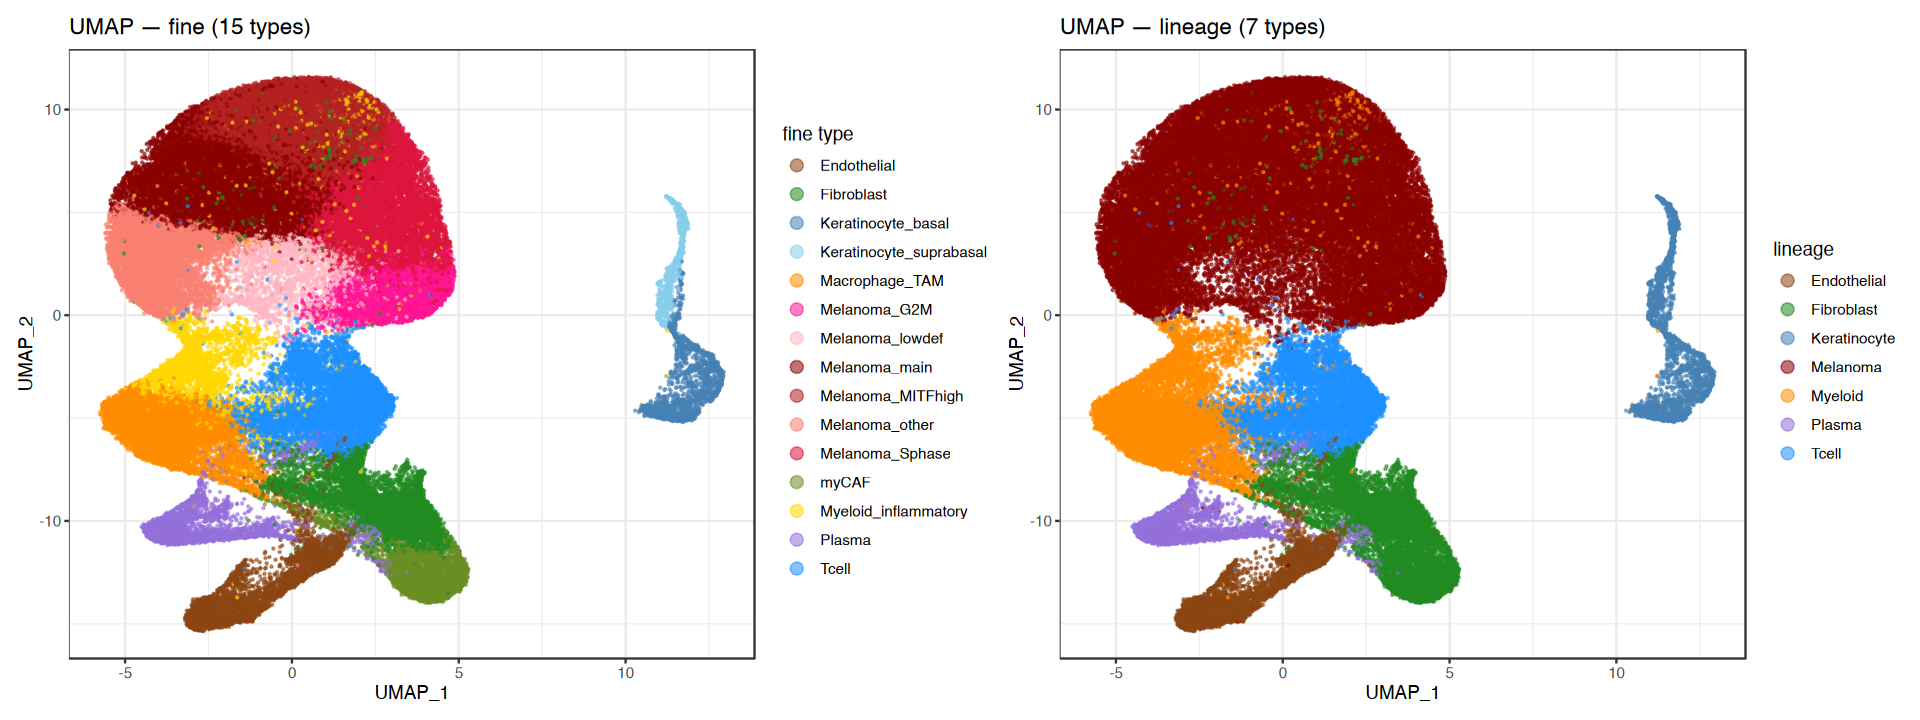

In [104]:
# Hand-grouped palettes — within-lineage shades for fine, base color for lineage
fine_colors <- c(
  "Melanoma_main"           = "#8B0000",
  "Melanoma_MITFhigh"       = "#B22222",
  "Melanoma_Sphase"         = "#DC143C",
  "Melanoma_G2M"            = "#FF1493",
  "Melanoma_other"          = "#FA8072",
  "Melanoma_lowdef"         = "#FFB6C1",
  "Macrophage_TAM"          = "#FF8C00",
  "Myeloid_inflammatory"    = "#FFD700",
  "Tcell"                   = "#1E90FF",
  "Plasma"                  = "#9370DB",
  "Fibroblast"              = "#228B22",
  "myCAF"                   = "#6B8E23",
  "Endothelial"             = "#8B4513",
  "Keratinocyte_basal"      = "#4682B4",
  "Keratinocyte_suprabasal" = "#87CEEB"
)

lineage_colors <- c(
  "Melanoma"     = "#8B0000",
  "Myeloid"      = "#FF8C00",
  "Tcell"        = "#1E90FF",
  "Plasma"       = "#9370DB",
  "Fibroblast"   = "#228B22",
  "Endothelial"  = "#8B4513",
  "Keratinocyte" = "#4682B4"
)

# UMAPs side-by-side
p_umap_fine <- ggplot(cells_meta_qc, aes(UMAP_1, UMAP_2, color = cell_type_fine)) +
  geom_point(size = 0.2, alpha = 0.55) +
  scale_color_manual(values = fine_colors, name = "fine type") +
  guides(color = guide_legend(override.aes = list(size = 3), ncol = 1)) +
  theme_bw() + labs(title = "UMAP — fine (15 types)")

p_umap_lineage <- ggplot(cells_meta_qc, aes(UMAP_1, UMAP_2, color = cell_type_lineage)) +
  geom_point(size = 0.2, alpha = 0.55) +
  scale_color_manual(values = lineage_colors, name = "lineage") +
  guides(color = guide_legend(override.aes = list(size = 3), ncol = 1)) +
  theme_bw() + labs(title = "UMAP — lineage (7 types)")

options(repr.plot.width = 16, repr.plot.height = 6)
p_umap_fine | p_umap_lineage

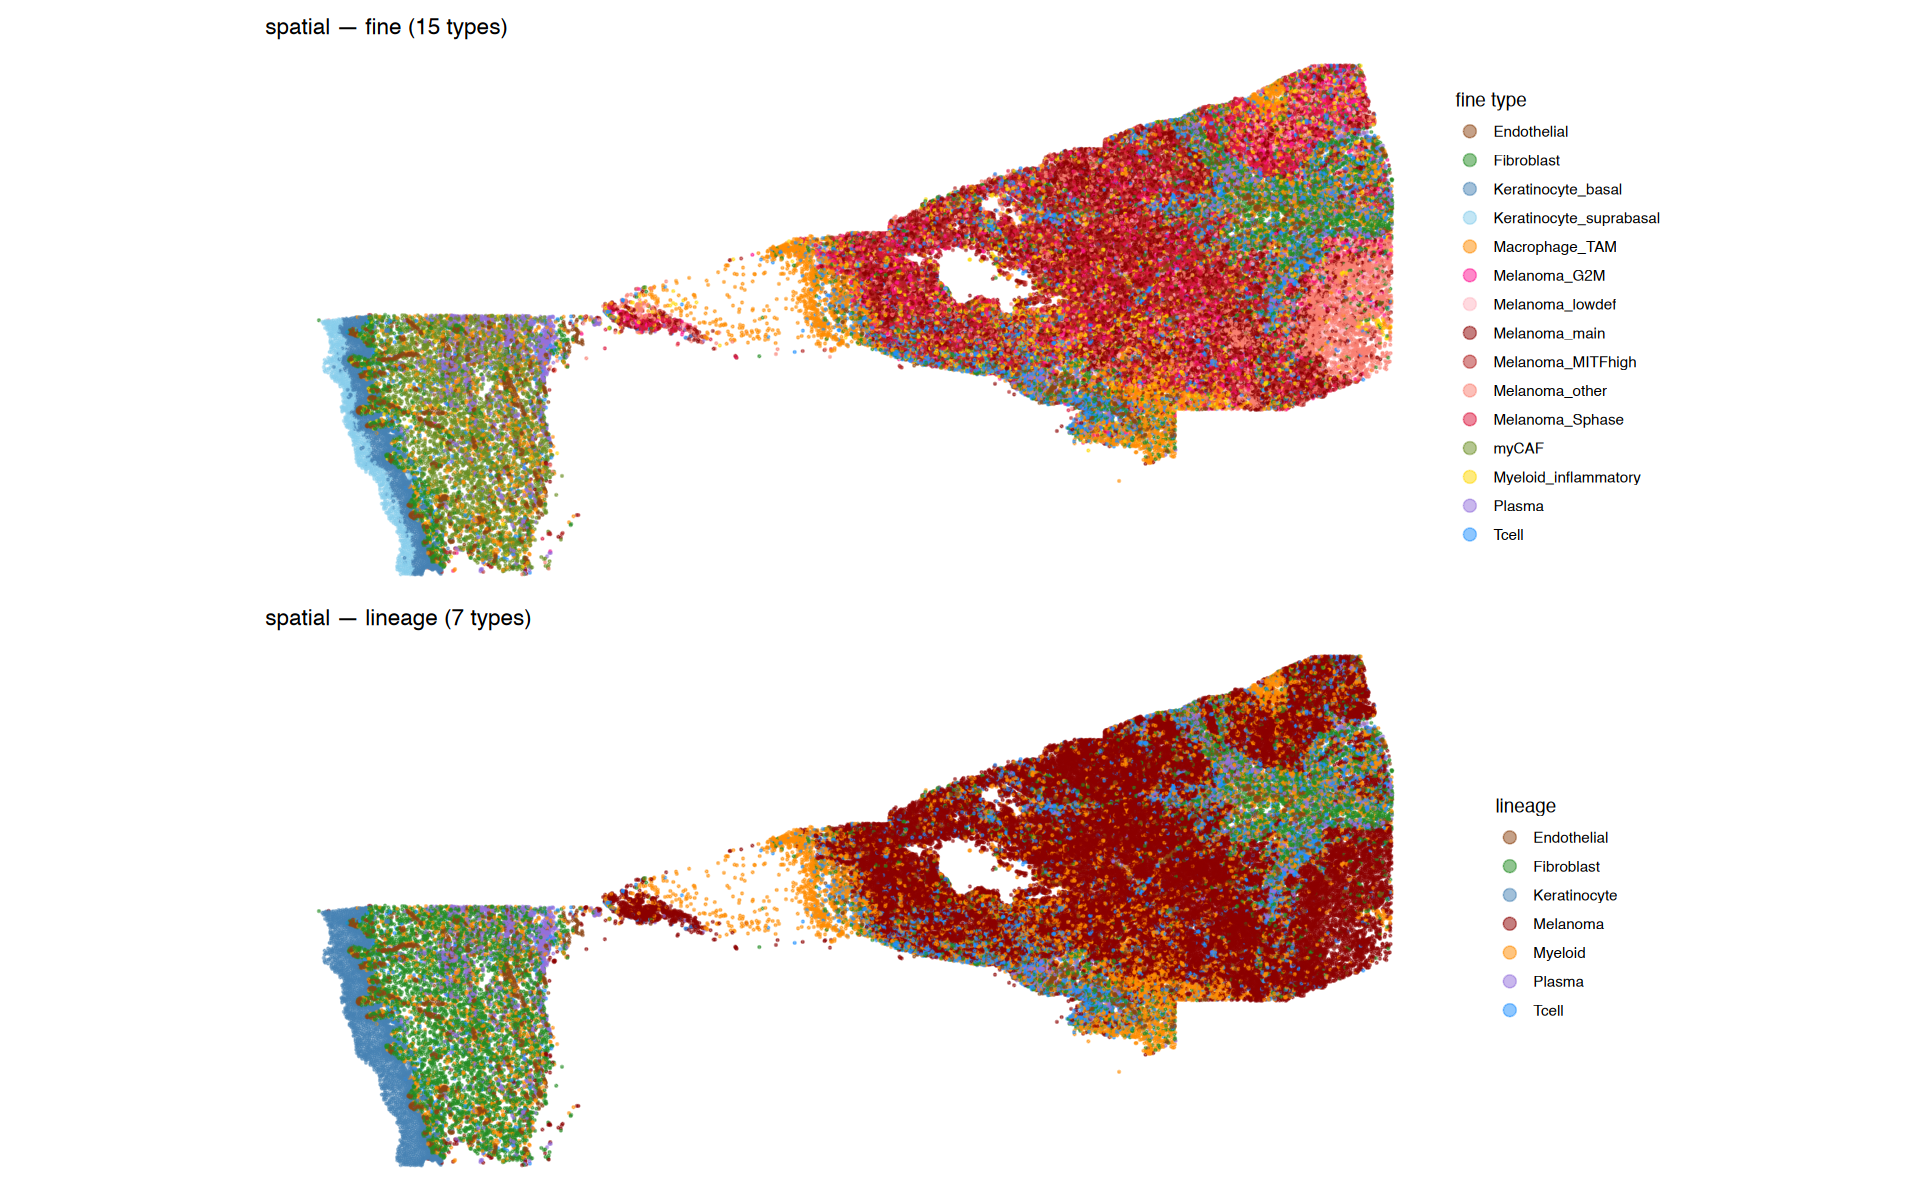

In [105]:
# Spatial — same cells, plotted at their (x_um, y_um) tissue coordinates
p_spatial_fine <- ggplot(cells_meta_qc, aes(x_um, y_um, color = cell_type_fine)) +
  geom_point(size = 0.15, alpha = 0.5) +
  scale_color_manual(values = fine_colors, name = "fine type") +
  guides(color = guide_legend(override.aes = list(size = 3), ncol = 1)) +
  coord_fixed() + scale_y_reverse() +
  theme_void() +
  labs(title = "spatial — fine (15 types)")

p_spatial_lineage <- ggplot(cells_meta_qc, aes(x_um, y_um, color = cell_type_lineage)) +
  geom_point(size = 0.15, alpha = 0.5) +
  scale_color_manual(values = lineage_colors, name = "lineage") +
  guides(color = guide_legend(override.aes = list(size = 3), ncol = 1)) +
  coord_fixed() + scale_y_reverse() +
  theme_void() +
  labs(title = "spatial — lineage (7 types)")

options(repr.plot.width = 16, repr.plot.height = 10)
p_spatial_fine / p_spatial_lineage

### 5d. Gene specificity — which genes drive which cell types?

For each gene, score how its probability mass is distributed across cell types. Three buckets:

- **`Specific_1`** — top type captures ≥60% of the mass. The gene is essentially a marker for one type.
- **`Shared_2`** — top1 < 60% AND top1+top2 ≥ 70%. The gene splits between two types.
- **`Non_specific`** — top1 < 40% AND ≥3 types each have >10%. Spread across many types — likely a housekeeping / broadly expressed gene that won't drive boundary detection.

Using the **lineage-level** matrix (7 types) for cleaner signal — at fine-level resolution most "shared" genes shared across cluster-of-the-same-lineage are biologically the same lineage, which is uninteresting. Switch to fine via `LEVEL_FOR_SPECIFICITY` if you want.

In [106]:
LEVEL_FOR_SPECIFICITY <- "lineage"  # or "fine"
counts_long <- if (LEVEL_FOR_SPECIFICITY == "lineage") gene_celltype_counts_lineage else gene_celltype_counts_fine

# Build class-frequency-unbiased per-gene probability vector:
#  (1) column-normalize counts → P(g | t), each column sums to 1
#  (2) row-renormalize → each gene's row sums to 1
# This removes the bias that would otherwise make all genes look "Melanoma-specific"
# in this dataset where ~54% of cells are Melanoma.
counts_wide <- counts_long |>
  tidyr::pivot_wider(names_from = cell_type, values_from = count, values_fill = 0)
counts_mat <- as.matrix(counts_wide[, -1])
rownames(counts_mat) <- counts_wide$gene
col_sums    <- pmax(colSums(counts_mat), 1)
p_g_given_t <- sweep(counts_mat, 2, col_sums, "/")          # P(g | t)
row_sums    <- pmax(rowSums(p_g_given_t), 1e-12)
p_unbiased  <- p_g_given_t / row_sums                       # each gene's row sums to 1

g2t <- as.data.frame(p_unbiased) |>
  tibble::rownames_to_column("gene") |>
  tidyr::pivot_longer(-gene, names_to = "cell_type", values_to = "prob")
K_levels <- ncol(p_unbiased)

gene_stats <- g2t |>
  group_by(gene) |>
  arrange(desc(prob), .by_group = TRUE) |>
  summarize(
    top1                = prob[1],
    top1_type           = cell_type[1],
    top2_sum            = sum(prob[1:min(2, n())]),
    top2_type           = cell_type[min(2, n())],
    n_types_above_10pct = sum(prob > 0.10),
    # Inverse Simpson's index = 1 / sum(p_i^2). Interpretation: the effective
    # number of cell types a gene is expressed in. ISI=1 → concentrated in one
    # type; ISI=K → uniform across all K types. Cleaner than entropy because
    # the units are interpretable ("equivalent to expression in N types").
    inv_simpson         = 1 / sum(prob ^ 2),
    entropy_norm        = -sum(ifelse(prob > 0, prob * log(prob), 0)) / log(K_levels),
    .groups = "drop"
  ) |>
  mutate(class = case_when(
    top1 >= 0.6                                ~ "Specific_1",
    top1 < 0.6 & top2_sum >= 0.7               ~ "Shared_2",
    top1 < 0.4 & n_types_above_10pct >= 3      ~ "Non_specific",
    TRUE                                       ~ "Intermediate"
  ))

# ─── Summary: how many genes per class, and what's their ISI distribution? ─
class_summary <- gene_stats |>
  group_by(class) |>
  summarize(
    n_genes     = n(),
    pct         = round(100 * n() / nrow(gene_stats), 1),
    isi_median  = round(median(inv_simpson), 2),
    isi_p25     = round(quantile(inv_simpson, 0.25), 2),
    isi_p75     = round(quantile(inv_simpson, 0.75), 2),
    top1_median = round(median(top1), 2),
    .groups = "drop"
  ) |>
  arrange(desc(n_genes))

cat(sprintf("Specificity summary (level = %s, K = %d cell types)\n",
            LEVEL_FOR_SPECIFICITY, K_levels))
cat(sprintf("ISI range:  1 = expressed in 1 type only,  %d = uniform across all types\n\n",
            K_levels))
print(class_summary, n = Inf)
cat(sprintf("\nOverall ISI:  median = %.2f,  mean = %.2f  (across %d genes)\n",
            median(gene_stats$inv_simpson), mean(gene_stats$inv_simpson),
            nrow(gene_stats)))

Specificity summary (level = lineage, K = 7 cell types)
ISI range:  1 = expressed in 1 type only,  7 = uniform across all types

# A tibble: 4 × 7
  class        n_genes   pct isi_median isi_p25 isi_p75 top1_median
  <chr>          <int> <dbl>      <dbl>   <dbl>   <dbl>       <dbl>
1 Non_specific    3236  64.6       5.87    4.96    6.5         0.25
2 Specific_1       714  14.3       1.76    1.32    2.13        0.74
3 Shared_2         540  10.8       2.8     2.59    3.11        0.52
4 Intermediate     516  10.3       3.56    3.3     3.84        0.46

Overall ISI:  median = 4.88,  mean = 4.60  (across 5006 genes)


Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_bar()`).”


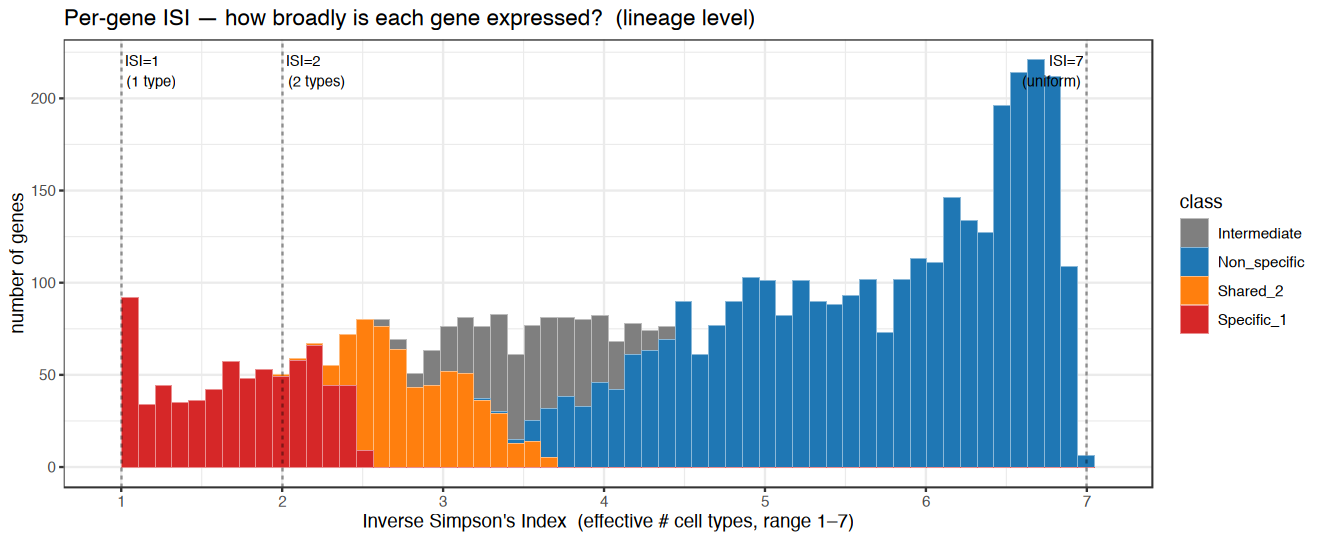

In [107]:
# ─── ISI histogram ────────────────────────────────────────────────────
options(repr.plot.width = 11, repr.plot.height = 4.5)
ggplot(gene_stats, aes(inv_simpson, fill = class)) +
  geom_histogram(bins = 60, color = "white", linewidth = 0.1) +
  scale_fill_manual(values = c("Specific_1" = "#D62728", "Shared_2" = "#FF7F0E",
                                "Intermediate" = "#7F7F7F", "Non_specific" = "#1F77B4")) +
  geom_vline(xintercept = c(1, 2, K_levels), linetype = "dashed", color = "black", alpha = 0.4) +
  annotate("text", x = 1,        y = Inf, label = "ISI=1\n(1 type)",
           vjust = 1.5, hjust = -0.1, size = 3, color = "black") +
  annotate("text", x = 2,        y = Inf, label = "ISI=2\n(2 types)",
           vjust = 1.5, hjust = -0.1, size = 3, color = "black") +
  annotate("text", x = K_levels, y = Inf, label = sprintf("ISI=%d\n(uniform)", K_levels),
           vjust = 1.5, hjust =  1.1, size = 3, color = "black") +
  scale_x_continuous(breaks = seq(1, K_levels, by = 1), limits = c(0.95, K_levels + 0.1)) +
  theme_bw() +
  labs(x = sprintf("Inverse Simpson's Index  (effective # cell types, range 1–%d)", K_levels),
       y = "number of genes",
       title = sprintf("Per-gene ISI — how broadly is each gene expressed?  (%s level)",
                       LEVEL_FOR_SPECIFICITY))

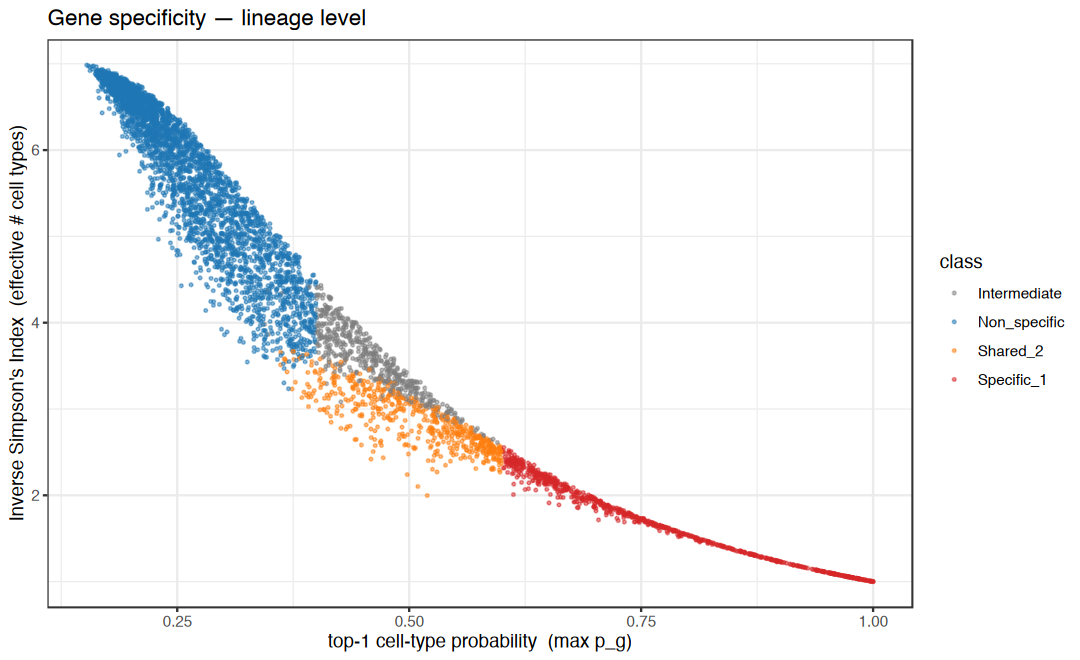

In [108]:
# ─── Scatter: top-1 mass vs ISI, colored by class ──────────────────────
options(repr.plot.width = 9, repr.plot.height = 5.5)
ggplot(gene_stats, aes(top1, inv_simpson, color = class)) +
  geom_point(size = 0.4, alpha = 0.5) +
  scale_color_manual(values = c("Specific_1" = "#D62728", "Shared_2" = "#FF7F0E",
                                 "Intermediate" = "#7F7F7F", "Non_specific" = "#1F77B4")) +
  theme_bw() +
  labs(x = "top-1 cell-type probability  (max p_g)",
       y = "Inverse Simpson's Index  (effective # cell types)",
       title = sprintf("Gene specificity — %s level", LEVEL_FOR_SPECIFICITY))

In [109]:
# Top examples per class
top_specific_1 <- gene_stats |>
  filter(class == "Specific_1") |>
  group_by(top1_type) |>
  slice_max(top1, n = 5, with_ties = FALSE) |>
  ungroup() |>
  arrange(top1_type, desc(top1))

top_shared_2 <- gene_stats |>
  filter(class == "Shared_2") |>
  arrange(desc(top2_sum)) |>
  head(20)

top_nonspecific <- gene_stats |>
  filter(class == "Non_specific") |>
  arrange(desc(entropy_norm)) |>
  head(20)

cat("=== Most-specific genes (top 5 per cell type) ===\n")
print(top_specific_1 |> select(gene, top1_type, top1, top2_sum), n = Inf)

cat("\n=== Top 20 two-type-shared genes ===\n")
print(top_shared_2 |> select(gene, top1_type, top2_type, top1, top2_sum), n = Inf)

cat("\n=== Top 20 non-specific genes (highest entropy) ===\n")
print(top_nonspecific |> select(gene, top1, top2_sum, n_types_above_10pct, entropy_norm), n = Inf)

=== Most-specific genes (top 5 per cell type) ===
# A tibble: 35 × 4
   gene     top1_type     top1 top2_sum
   <chr>    <chr>        <dbl>    <dbl>
 1 CDH5     Endothelial  0.985    0.990
 2 SELE     Endothelial  0.985    0.993
 3 KDR      Endothelial  0.984    0.988
 4 PLVAP    Endothelial  0.983    0.987
 5 CLEC14A  Endothelial  0.982    0.988
 6 MASP1    Fibroblast   0.856    0.938
 7 APELA    Fibroblast   0.827    0.953
 8 SAA4     Fibroblast   0.822    0.954
 9 LGR5     Fibroblast   0.813    0.969
10 SVEP1    Fibroblast   0.809    0.944
11 DSG1     Keratinocyte 0.999    1.000
12 A2ML1    Keratinocyte 0.999    0.999
13 CDSN     Keratinocyte 0.998    0.998
14 ARG1     Keratinocyte 0.998    0.998
15 DSG3     Keratinocyte 0.997    0.998
16 CYP2A6   Melanoma     1        1    
17 SRY      Melanoma     1        1    
18 TRPM1    Melanoma     0.703    0.837
19 DLL3     Melanoma     0.680    0.817
20 MAGEC1   Melanoma     0.677    0.867
21 MMP12    Myeloid      0.796    0.853
22 RETN    

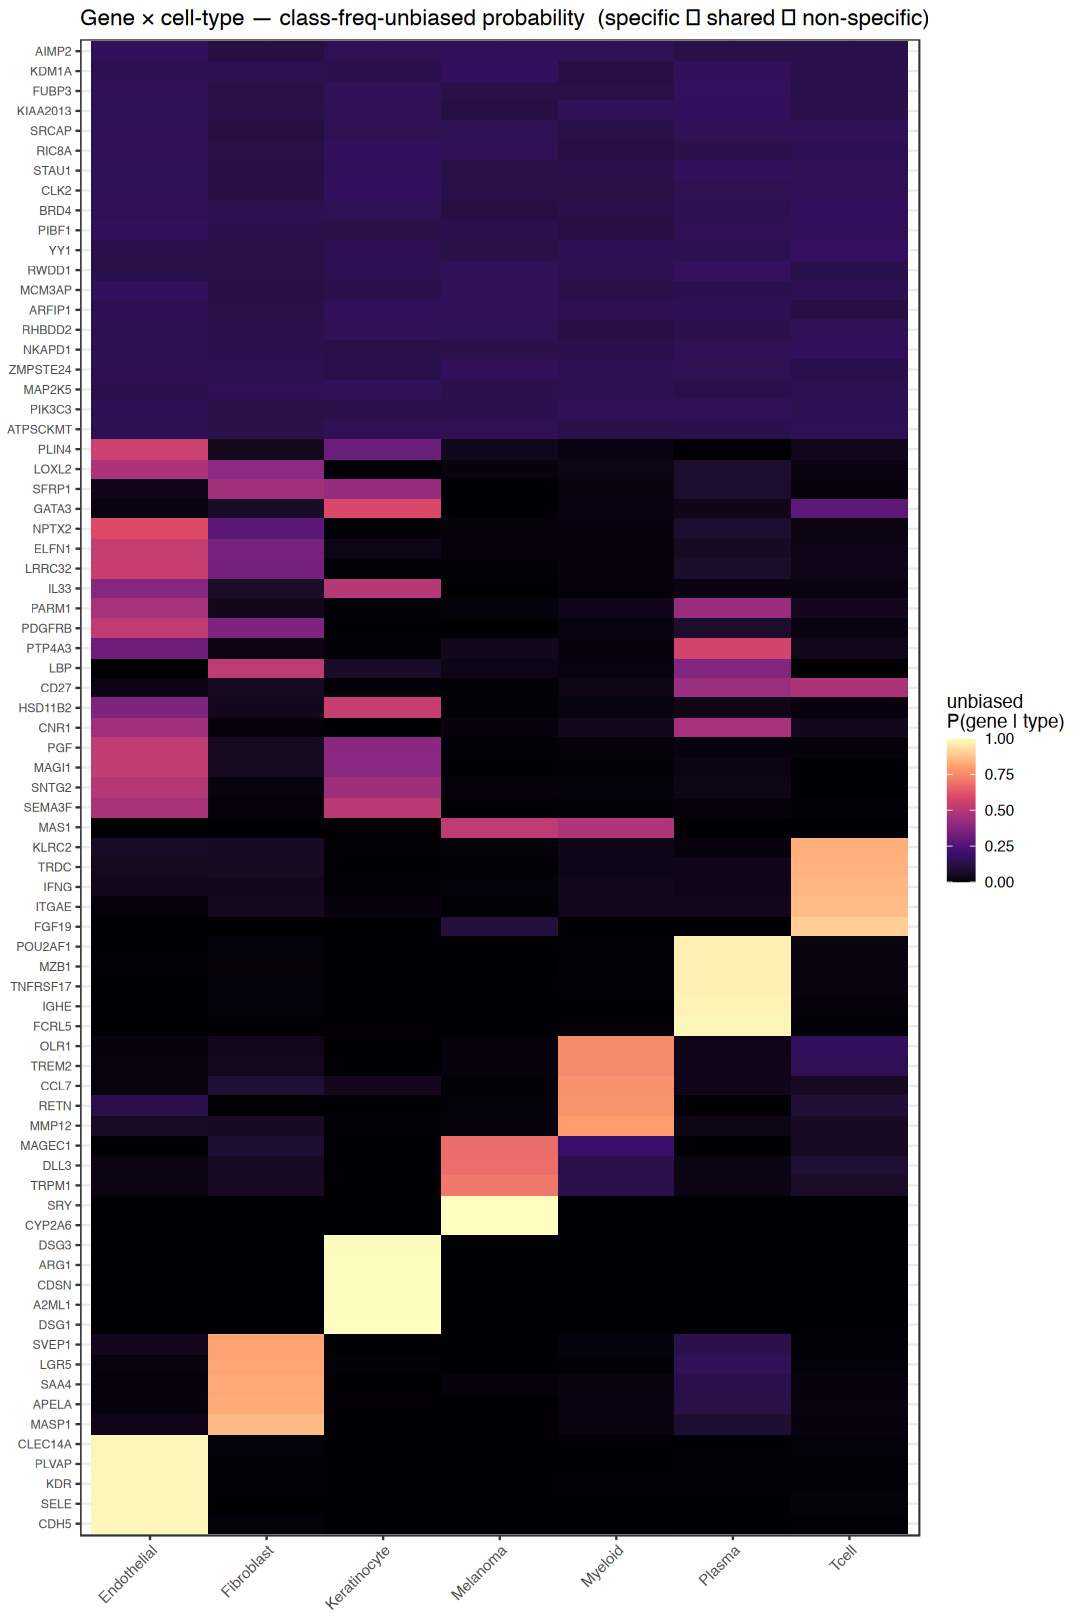

In [110]:
# Heatmap of representative genes — gene × cell_type probability matrix
display_genes <- unique(c(
  top_specific_1$gene,
  top_shared_2$gene,
  top_nonspecific$gene
))

heatmap_df <- g2t |>
  filter(gene %in% display_genes) |>
  mutate(gene = factor(gene, levels = c(
    top_specific_1$gene,
    setdiff(top_shared_2$gene,    top_specific_1$gene),
    setdiff(top_nonspecific$gene, c(top_specific_1$gene, top_shared_2$gene))
  )))

options(repr.plot.width = 9,
        repr.plot.height = max(8, length(display_genes) * 0.18))
ggplot(heatmap_df, aes(cell_type, gene, fill = prob)) +
  geom_tile() +
  scale_fill_viridis_c(option = "magma", limits = c(0, 1),
                       name = "unbiased\nP(gene | type)") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        axis.text.y = element_text(size = 7)) +
  labs(title = "Gene × cell-type — class-freq-unbiased probability  (specific → shared → non-specific)",
       x = NULL, y = NULL)

### 5e. Assign each gene a single cell-type label (or "ambiguous")

Per-gene labeling decision lives here so downstream consumers (notebook 01) don't re-implement it. The transformation used is the same one notebook 01 §3.1 uses for its embedding (column-normalize counts → row z-score per gene), so labels are consistent with the embedding the gradient pipeline sees.

**Two-step labeling (both reported):**

1. **Assign** — for every gene, find argmax across types (its strongest type by z-score). At this stage every gene has a `top_type`, regardless of specificity.
2. **Filter** — relabel any gene whose z-pattern is NOT "z>0 in exactly 1 type, z<0 in all other K-1" as `"ambiguous"`. The remaining genes keep their `top_type` as label.

Exported as `gene_labels_lineage.parquet` with cols `(gene, label, z_top)`. Notebook 01 just consumes the labels — no filter logic there.

In [111]:
# ─── Build the same embedding notebook 01 §3.1 uses ───────────────────
counts_wide_l <- tidyr::pivot_wider(gene_celltype_counts_lineage,
                                     names_from = cell_type,
                                     values_from = count,
                                     values_fill = 0)
cell_type_cols_l <- setdiff(colnames(counts_wide_l), "gene")
K_l              <- length(cell_type_cols_l)

counts_mat_l <- as.matrix(counts_wide_l[, cell_type_cols_l])
rownames(counts_mat_l) <- counts_wide_l$gene

# Column-normalize: P(gene | type)
col_sums_l <- pmax(colSums(counts_mat_l), 1)
p_g_t_l    <- sweep(counts_mat_l, 2, col_sums_l, "/")

# Z-score each gene's row (across types)
zscore_row <- function(x) {
  m <- mean(x); s <- sd(x)
  if (is.na(s) || s < 1e-12) return(rep(0, length(x)))
  (x - m) / s
}
emb_l <- t(apply(p_g_t_l, 1, zscore_row))
colnames(emb_l) <- cell_type_cols_l

cat(sprintf("embedding: %d genes × %d cell types\n", nrow(emb_l), K_l))

embedding: 5006 genes × 7 cell types


In [112]:
# ─── Step 1: assign each gene a top_type via argmax ────────────────────
top_col_idx <- max.col(emb_l, ties.method = "first")
top_type    <- cell_type_cols_l[top_col_idx]
z_top       <- emb_l[cbind(seq_len(nrow(emb_l)), top_col_idx)]

cat("=== Step 1 ASSIGN — top type for every gene (by z-score argmax) ===\n")
cat(sprintf("Total: %d genes\n", nrow(emb_l)))
cat("Genes per assigned top type:\n")
print(sort(table(top_type), decreasing = TRUE))

=== Step 1 ASSIGN — top type for every gene (by z-score argmax) ===
Total: 5006 genes
Genes per assigned top type:
top_type
Keratinocyte     Melanoma        Tcell  Endothelial       Plasma   Fibroblast 
         917          817          777          758          715          518 
     Myeloid 
         504 


In [113]:
# ─── Step 2: filter — relabel non-strict-specific genes as "ambiguous" ─
# Strict-specific = z>0 in exactly 1 type AND z<0 in all other K-1
n_pos <- rowSums(emb_l > 0)
n_neg <- rowSums(emb_l < 0)
is_specific <- (n_pos == 1) & (n_neg == K_l - 1)

label <- ifelse(is_specific, top_type, "ambiguous")

cat("=== Step 2 FILTER — relabel non-strict-specific as 'ambiguous' ===\n")
cat(sprintf("Kept as specific:   %d of %d (%.1f%%)\n",
            sum(is_specific), length(label), 100 * mean(is_specific)))
cat(sprintf("Relabeled ambiguous: %d of %d (%.1f%%)\n",
            sum(!is_specific), length(label), 100 * mean(!is_specific)))
cat("\nFinal label distribution:\n")
print(sort(table(label), decreasing = TRUE))

=== Step 2 FILTER — relabel non-strict-specific as 'ambiguous' ===
Kept as specific:   679 of 5006 (13.6%)
Relabeled ambiguous: 4327 of 5006 (86.4%)

Final label distribution:
label
   ambiguous Keratinocyte  Endothelial        Tcell       Plasma      Myeloid 
        4327          239          141           89           79           51 
  Fibroblast     Melanoma 
          41           39 


In [114]:
# ─── Assemble final per-gene label table ──────────────────────────────
gene_labels_lineage <- data.frame(
  gene  = rownames(emb_l),
  label = label,
  z_top = z_top,
  row.names = NULL
)
head(gene_labels_lineage |> dplyr::arrange(label, desc(z_top)), 14)

,gene,label,z_top
,<chr>,<chr>,<dbl>
1,KDR,Endothelial,2.267778
2,PLVAP,Endothelial,2.267765
3,CDH5,Endothelial,2.267764
4,CD34,Endothelial,2.267760
5,CLEC14A,Endothelial,2.267759
6,MMRN2,Endothelial,2.267756
7,EGFL7,Endothelial,2.267753
8,SOX18,Endothelial,2.267748
9,NOTCH4,Endothelial,2.267740


## 6. Export to parquet

Three files:
- **Raw count matrices** (fine, lineage) — no normalization, downstream consumers normalize as needed.
- **Per-gene lineage labels** — each gene gets one of the 7 lineage names OR `"ambiguous"`, decided in §5e. This is what notebook 01 reads to filter transcripts.

In [115]:
out_fine    <- file.path(DATA_ROOT, "gene_celltype_counts_fine.parquet")
out_lineage <- file.path(DATA_ROOT, "gene_celltype_counts_lineage.parquet")
out_labels  <- file.path(DATA_ROOT, "gene_labels_lineage.parquet")

write_parquet(gene_celltype_counts_fine,    out_fine)
write_parquet(gene_celltype_counts_lineage, out_lineage)
write_parquet(gene_labels_lineage,          out_labels)

cat(sprintf("wrote %s\n  %d rows, %d genes × %d types\n",
            out_fine,    nrow(gene_celltype_counts_fine),
            n_distinct(gene_celltype_counts_fine$gene),
            n_distinct(gene_celltype_counts_fine$cell_type)))
cat(sprintf("wrote %s\n  %d rows, %d genes × %d types\n",
            out_lineage, nrow(gene_celltype_counts_lineage),
            n_distinct(gene_celltype_counts_lineage$gene),
            n_distinct(gene_celltype_counts_lineage$cell_type)))
cat(sprintf("wrote %s\n  %d genes labeled\n",
            out_labels, nrow(gene_labels_lineage)))

wrote /Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs/gene_celltype_counts_fine.parquet
  75090 rows, 5006 genes × 15 types
wrote /Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs/gene_celltype_counts_lineage.parquet
  35042 rows, 5006 genes × 7 types
wrote /Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs/gene_labels_lineage.parquet
  5006 genes labeled


---

**Handoff format (locked):**

| File | Format | Cols |
|---|---|---|
| `gene_celltype_counts_fine.parquet`    | parquet (long) | `gene`, `cell_type`, `count` — raw 15-type matrix |
| `gene_celltype_counts_lineage.parquet` | parquet (long) | `gene`, `cell_type`, `count` — raw 7-type matrix |
| `gene_labels_lineage.parquet`          | parquet (one row / gene) | `gene`, `label`, `z_top` — label ∈ {7 lineage names, "ambiguous"} |

Notebook 01 reads `gene_labels_lineage.parquet` and filters transcripts to `label != "ambiguous"` before plotting. No re-implementation of the filter logic in notebook 01.